In [1]:
import sys
from pathlib import Path

def add_src_to_path():
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        src = p / "src"
        if src.is_dir():
            sys.path.insert(0, str(src))
            print(f"✅ Added to sys.path: {src}")
            return src
    raise FileNotFoundError(
        f"Could not find a 'src' directory by walking up from {here}.\n"
        f"Current working dir is: {here}"
    )

SRC_DIR = add_src_to_path()
print("First sys.path entry:", sys.path[0])


✅ Added to sys.path: /home/user/src
First sys.path entry: /home/user/src


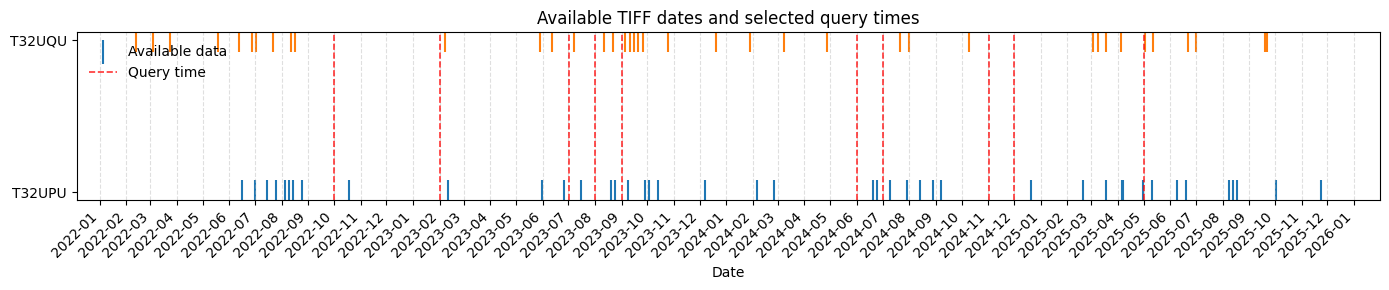

In [2]:
import os
import glob
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.dates as mdates


folders = [
    "/home/user/data/extended_area_experiment_data/T32UPU",
    "/home/user/data/extended_area_experiment_data/T32UQU",
]

query_times = [
    datetime(2022, 10, 1, 10, 0, 0),
    datetime(2023, 2, 1, 10, 0, 0),
    datetime(2023, 7, 1, 10, 0, 0),
    datetime(2023, 8, 1, 10, 0, 0),
    datetime(2023, 9, 1, 10, 0, 0),
    datetime(2024, 6, 1, 10, 0, 0),
    datetime(2024, 7, 1, 10, 0, 0),
    datetime(2024, 11, 1, 10, 0, 0),
    datetime(2024, 12, 1, 10, 0, 0),
    datetime(2025, 5, 1, 10, 0, 0),
]

def list_datetimes(folder: str):
    paths = sorted(glob.glob(os.path.join(folder, "*.tif")))
    dts = []
    for p in paths:
        base = os.path.basename(p)
        name, _ = os.path.splitext(base)
        try:
            dt = datetime.strptime(name, "%Y%m%dT%H%M%S")
            dts.append(dt)
        except ValueError:
            continue
    return sorted(dts)

tile_to_dts = {os.path.basename(f): list_datetimes(f) for f in folders}

# ---- Plot ----
fig, ax = plt.subplots(figsize=(14, 3))

tiles = list(tile_to_dts.keys())
for i, tile in enumerate(tiles):
    dts = tile_to_dts[tile]
    ax.scatter(dts, [i] * len(dts), marker="|", s=300, label="Available data" if i == 0 else None)

# ---- Overlay query times ----
for qt in query_times:
    ax.axvline(
        qt,
        color="red",
        linestyle="--",
        linewidth=1.2,
        alpha=0.8,
        label="Query time" if qt == query_times[0] else None,
    )

ax.set_yticks(range(len(tiles)))
ax.set_yticklabels(tiles)
ax.set_xlabel("Date")
ax.set_title("Available TIFF dates and selected query times")

# Monthly ticks
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

ax.grid(True, axis="x", linestyle="--", alpha=0.4)

ax.legend(loc="upper left", frameon=False)
fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.show()


In [3]:
query_times = [
    datetime(2022, 10, 1, 10, 0, 0),
    datetime(2023, 2, 1, 10, 0, 0),
    datetime(2023, 7, 1, 10, 0, 0),
    datetime(2023, 8, 1, 10, 0, 0),
    datetime(2023, 9, 1, 10, 0, 0),
    datetime(2024, 6, 1, 10, 0, 0),
    datetime(2024, 7, 1, 10, 0, 0),
    datetime(2024, 11, 1, 10, 0, 0),
    datetime(2024, 12, 1, 10, 0, 0),
    datetime(2025, 5, 1, 10, 0, 0),
]

In [4]:
import os, glob, math
import numpy as np
import rasterio as rio
import torch
from torch.utils.data import Dataset, DataLoader
from datetime import datetime
from models.LIANet import LIANetLight
from utils import _preprocess_S2

def _preprocess_S2(patch):
    patch = patch.astype(np.float32)
    patch = patch - 1000
    patch = patch / 10000
    patch = np.clip(patch, 0, 1)
    return patch


def _time_features(dt: datetime):
    t0 = datetime(2015, 1, 1)
    delta_days = (dt - t0).total_seconds() / 86400.0
    doy = dt.timetuple().tm_yday
    doy_norm = (doy - 1) / 365.0
    doy_sin = math.sin(2 * math.pi * doy_norm)
    doy_cos = math.cos(2 * math.pi * doy_norm)
    return delta_days, doy_sin, doy_cos


class LIANetFixedGridQueryDataset(Dataset):
    """
    Deterministic dataset: (tile, x_img, y_img) from a fixed grid, combined with query_times.
    Also returns x_s2,y_s2 in the same *style* you used (per-tile latent positions).
    No raster reading.
    """
    def __init__(
        self,
        image_size: int,
        complete_tile_size: int,
        tile_names: list,
        query_times: list,                # list[datetime]
        grid_step: int = 1000,
        overlap_x: int = 984,            # only used for x_s2; doesn't affect reading
    ):
        self.image_size = image_size
        self.complete_tile_size = complete_tile_size
        self.tile_names = tile_names
        self.query_times = query_times
        self.grid_step = grid_step
        self.overlap_x = overlap_x

        # grid points in IMAGE space; ensure patch fits
        xs = list(range(0, 10980 - image_size + 1, grid_step))
        ys = list(range(0, 10980 - image_size + 1, grid_step))
        self.xy = [(x, y) for y in ys for x in xs]

        self.n_xy = len(self.xy)
        self.n_t = len(self.query_times)
        self.n_tiles = len(self.tile_names)

    def __len__(self):
        return self.n_tiles * self.n_t * self.n_xy

    def __getitem__(self, idx):
        # idx -> tile_i, t_i, xy_i
        xy_i = idx % self.n_xy
        tmp = idx // self.n_xy
        t_i = tmp % self.n_t
        tile_i = tmp // self.n_t

        tile_name = self.tile_names[tile_i]
        x_img, y_img = self.xy[xy_i]
        dt = self.query_times[t_i]
        delta_days, doy_sin, doy_cos = _time_features(dt)

        # Make x_s2,y_s2 in the same "latent canvas" convention as you used:
        # NOTE: this is only for the model input; the real data read will use x_img,y_img inside each tile.
        x_s2 = tile_i * self.complete_tile_size + x_img - self.overlap_x
        y_s2 = y_img
        # keep inside your extended limits if you want (optional). Here we just keep as-is.

        return {
            "tile_name": tile_name,
            "x_img": torch.tensor(x_img, dtype=torch.int32),
            "y_img": torch.tensor(y_img, dtype=torch.int32),
            "x_s2": torch.tensor(x_s2, dtype=torch.int32),
            "y_s2": torch.tensor(y_s2, dtype=torch.int32),

            "delta_days": torch.tensor(delta_days, dtype=torch.float32),
            "doy_sin": torch.tensor(doy_sin, dtype=torch.float32),
            "doy_cos": torch.tensor(doy_cos, dtype=torch.float32),

            "t_query_str": dt.strftime("%Y%m%dT%H%M%S"),
            "xy_index": torch.tensor(xy_i, dtype=torch.int32),
            "t_index": torch.tensor(t_i, dtype=torch.int32),
            "tile_index": torch.tensor(tile_i, dtype=torch.int32),
        }


In [5]:
dl_query = DataLoader(
    LIANetFixedGridQueryDataset(
        image_size=64,
        complete_tile_size=20976,
        tile_names=[os.path.basename(f) for f in folders],
        query_times=query_times,
        grid_step=1000,
        overlap_x=984,
    ),
    batch_size=128,
    shuffle=False,
    num_workers=4,
)

In [6]:
def list_training_files(topdir_dataset, tile_name, exclude_year_prefix=None):
    tile_dir = os.path.join(topdir_dataset, tile_name)
    files = [f for f in os.listdir(tile_dir) if f.endswith(".tif")]
    if exclude_year_prefix is not None:
        files = [f for f in files if not f.startswith(str(exclude_year_prefix))]
    files = sorted(files)
    return files


In [13]:
import torch.nn.functional as F

def run_inference_and_similarity(
    model,
    query_loader,
    topdir_dataset,
    train_files_by_tile,   # dict: {tile_name: [filename1.tif, ...]}
    image_size: int,
    device,
    topk: int = 5,
):
    """
    Returns a list of dicts, one per (tile, query_time, xy) item, with top-k matching training timestamps.
    Similarity metrics:
      - cosine similarity on flattened patch
      - mse (lower is better)
    """
    model.eval()
    m = model.module if hasattr(model, "module") else model

    results = []

    with torch.no_grad():
        for batch in query_loader:
            # ---- move model inputs ----
            x_s2 = batch["x_s2"].to(device)
            y_s2 = batch["y_s2"].to(device)
            delta_days = batch["delta_days"].to(device)
            doy_sin = batch["doy_sin"].to(device)
            doy_cos = batch["doy_cos"].to(device)

            if m.time_mode == "index":
                # query dataset does not provide time_idx (and your queries are "not in training")
                # so this mode can't be used for off-grid timestamps.
                raise ValueError("time_mode='index' cannot handle query timestamps not in training.")
            elif m.time_mode in ("sinusoidal", "fourier_learned"):
                pred = model(delta_days, x_s2, y_s2)
            elif m.time_mode == "mlp":
                time_features = torch.stack([delta_days, doy_sin, doy_cos], dim=1)
                pred = model(time_features, x_s2, y_s2)
            else:
                raise ValueError(f"Unknown time_mode: {m.time_mode}")

            # pred: (B, C, H, W)
            B = pred.shape[0]
            # print(f"Processing batch with {pred.shape} samples...")

            # ---- for each sample in batch, compare to all training timestamps of its tile ----
            # keep small/simple: loop samples; (B is usually small)
            for i in range(B):
                tile_name = batch["tile_name"][i]
                x_img = int(batch["x_img"][i].item())
                y_img = int(batch["y_img"][i].item())
                t_query_str = batch["t_query_str"][i]
                xy_index = int(batch["xy_index"][i].item())
                t_index = int(batch["t_index"][i].item())

                pred_i = pred[i].detach().cpu()  # (C,H,W) on CPU for similarity

                # compare to every training file of this tile
                sims_cos = []
                sims_mse = []
                train_names = train_files_by_tile[tile_name]

                # One window for all reads
                window = rio.windows.Window(
                    col_off=x_img, row_off=y_img, width=image_size, height=image_size
                )

                tile_dir = os.path.join(topdir_dataset, tile_name)

                for f_name in train_names:
                    f_path = os.path.join(tile_dir, f_name)
                    with rio.open(f_path) as src:
                        real = src.read(window=window)   # (C,H,W) numpy
                    real = _preprocess_S2(real)          # should return torch or numpy; handle both
                    if not torch.is_tensor(real):
                        real = torch.from_numpy(real)
                    device = torch.device(f"cuda:0") # or just "cuda:0"

                    real = real.to(device)
                    pred_i = pred_i.to(device)
                    
                    # print(real.shape)
                    # print(pred_i.shape)
                    # flatten for cosine
                    a = pred_i.reshape(-1).float()
                    b = real.reshape(-1).float()

                    cos = F.cosine_similarity(a[None, :], b[None, :]).item()
                    mse = F.mse_loss(pred_i.float(), real.float()).item()

                    sims_cos.append(cos)
                    sims_mse.append(mse)

                sims_cos = np.array(sims_cos)
                sims_mse = np.array(sims_mse)

                # topk by cosine (higher better)
                top_idx = np.argsort(-sims_cos)[:topk]
                topk_list = []
                for j in top_idx:
                    topk_list.append({
                        "train_file": train_names[j],
                        "cosine": float(sims_cos[j]),
                        "mse": float(sims_mse[j]),
                    })

                results.append({
                    "tile_name": tile_name,
                    "t_query_str": t_query_str,
                    "xy_index": xy_index,
                    "t_index": t_index,
                    "x_img": x_img,
                    "y_img": y_img,
                    "topk": topk_list,
                    # optionally store full arrays if you want later plots (can be large)
                    # "all_cosine": sims_cos,
                    # "all_mse": sims_mse,
                })

    return results


In [ ]:
import torch
from collections import OrderedDict
from datetime import datetime

topdir = "/home/user/data/extended_area_experiment_data" 
tile_names = ["T32UPU", "T32UQU"] 
image_size = 128 

ds_query = LIANetFixedGridQueryDataset( image_size=image_size, complete_tile_size=20976, tile_names=tile_names, query_times=query_times, grid_step=1000, ) 
dl_query = DataLoader(ds_query, batch_size=8, shuffle=False, num_workers=4) 
train_files_by_tile = { t: list_training_files(topdir, t, exclude_year_prefix=2024) for t in tile_names }
# device = torch.device(f"cuda:0") # or just "cuda:0"

model = LIANetLight(
    timestamp_dim=43, 
    time_mode="fourier_learned", 
    num_time_frequencies=8, 
    time_input_dim=3, 
    time_mlp_hidden=64, 
    levels=13, 
    n_min=16, 
    growth=2, 
    table_size=524288, # 2^19 
    feat_dim=128, 
    complete_tile_size=20976, # Sentinel-2 max tile size 
    resunet_backbone_size="small", 
    bilinear=True, 
    out_channels=12, 
    preproj_channels=128 
    )

# ckpt_path = "/home/user/pretraining_results/fourier_learned_2tile_alltimes/2026-01-06_18-17-35/model_checkpoints/checkpoint_Epoch400_Iteration800000.pt"
ckpt_path = "/home/user/results_shared/fourier_learned_2tile_alltimes_USA/2026-01-15_12-33-30/model_checkpoints/checkpoint_Epoch1601_Iteration3200000.pt"
def normalize_state_dict_keys(state_dict):
    """
    Make checkpoint keys compatible across common wrappers:
    - DDP:        'module.'
    - torch.compile / wrappers: '_orig_mod.'
    """
    new_state = OrderedDict()
    for k, v in state_dict.items():
        # peel off multiple possible prefixes (order matters)
        for prefix in ("module.", "_orig_mod."):
            if k.startswith(prefix):
                k = k[len(prefix):]
        new_state[k] = v
    return new_state

ckpt = torch.load(ckpt_path, map_location="cuda:0")

if isinstance(ckpt, dict):
    if "model_state_dict" in ckpt:
        state = ckpt["model_state_dict"]
    elif "state_dict" in ckpt:
        state = ckpt["state_dict"]
    elif "model" in ckpt:
        state = ckpt["model"]
    else:
        state = ckpt
else:
    raise ValueError("Checkpoint is not a dict.")

new_state = normalize_state_dict_keys(state)

missing, unexpected = model.load_state_dict(new_state, strict=False)
print("Missing keys:", len(missing))
print("Unexpected keys:", len(unexpected))
if len(missing) < 50 and len(unexpected) < 50:
    print("Missing:", missing)
    print("Unexpected:", unexpected)

device = torch.device(f"cuda:0") # or just "cuda:0"

model = model.to(device) 
model.eval()


Missing keys: 0
Unexpected keys: 0
Missing: []
Unexpected: []


LIANetLight(
  (encoder): HashTableEncoder2D()
  (time_encoder): LearnedFourierTimeEncoder1D(
    (proj): Linear(in_features=16, out_features=1664, bias=True)
  )
  (preproj): Conv2d(1664, 128, kernel_size=(1, 1), stride=(1, 1))
  (light_head): LiteCNNHead(
    (stem): Sequential(
      (0): Conv2d(128, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): GroupNorm(16, 256, eps=1e-05, affine=True)
      (2): GELU(approximate='none')
    )
    (blocks): Sequential(
      (0): ConvResBlock(
        (block): Sequential(
          (0): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): GroupNorm(16, 256, eps=1e-05, affine=True)
          (2): GELU(approximate='none')
          (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (4): GroupNorm(16, 256, eps=1e-05, affine=True)
        )
        (act): GELU(approximate='none')
      )
      (1): ConvResBlock(
        (block): Sequential(
         

In [21]:
results = run_inference_and_similarity(
    model=model,
    query_loader=dl_query,
    topdir_dataset=topdir,
    train_files_by_tile=train_files_by_tile,
    image_size=image_size,
    device=device,
    topk=5,
)

# inspect one example
results[0]

{'tile_name': 'T32UPU',
 't_query_str': '20221001T100000',
 'xy_index': 0,
 't_index': 0,
 'x_img': 0,
 'y_img': 0,
 'topk': [{'train_file': '20230715T101601.tif',
   'cosine': 0.9181582927703857,
   'mse': 0.0045380438677966595},
  {'train_file': '20230819T101609.tif',
   'cosine': 0.9108843803405762,
   'mse': 0.010855648666620255},
  {'train_file': '20220630T102041.tif',
   'cosine': 0.8986421227455139,
   'mse': 0.023808320984244347},
  {'train_file': '20230625T101601.tif',
   'cosine': 0.8977479338645935,
   'mse': 0.014679484069347382},
  {'train_file': '20250619T101559.tif',
   'cosine': 0.895855188369751,
   'mse': 0.018931355327367783}]}

In [22]:
import pandas as pd
import numpy as np
from datetime import datetime
import math

def parse_dt_from_query_str(s):
    return datetime.strptime(s, "%Y%m%dT%H%M%S")

def parse_dt_from_train_file(f):
    # "YYYYMMDDTHHMMSS.tif"
    base = f.replace(".tif", "")
    return datetime.strptime(base, "%Y%m%dT%H%M%S")

def doy(dt):
    return dt.timetuple().tm_yday

def circular_doy_dist(d1, d2):
    # d1,d2 are DOY in [1..365/366]
    diff = abs(d1 - d2)
    return min(diff, 365 - diff)

rows = []
for r in results:
    qdt = parse_dt_from_query_str(r["t_query_str"])
    qdoy = doy(qdt)

    # top-1 match
    best = r["topk"][0]
    tdt = parse_dt_from_train_file(best["train_file"])
    tdoy = doy(tdt)

    rows.append({
        "tile": r["tile_name"],
        "x_img": r["x_img"],
        "y_img": r["y_img"],
        "t_query": qdt,
        "t_train_nn": tdt,
        "doy_query": qdoy,
        "doy_nn": tdoy,
        "doy_dist": circular_doy_dist(qdoy, tdoy),
        "abs_days_dist": abs((tdt - qdt).days),
        "cosine_nn": best["cosine"],
        "mse_nn": best["mse"],
    })

df = pd.DataFrame(rows)
df.head()


,tile,x_img,y_img,t_query,t_train_nn,doy_query,doy_nn,doy_dist,abs_days_dist,cosine_nn,mse_nn
0,T32UPU,0,0,2022-10-01 10:00:00,2023-07-15 10:16:01,274,196,78,287,0.918158,0.004538
1,T32UPU,1000,0,2022-10-01 10:00:00,2022-08-14 10:15:59,274,226,48,48,0.939229,0.010330
2,T32UPU,2000,0,2022-10-01 10:00:00,2023-07-15 10:16:01,274,196,78,287,0.937128,0.006609
3,T32UPU,3000,0,2022-10-01 10:00:00,2025-08-13 10:20:41,274,225,49,1047,0.950329,0.005333
4,T32UPU,4000,0,2022-10-01 10:00:00,2025-04-05 10:20:41,274,95,179,917,0.921072,0.007635


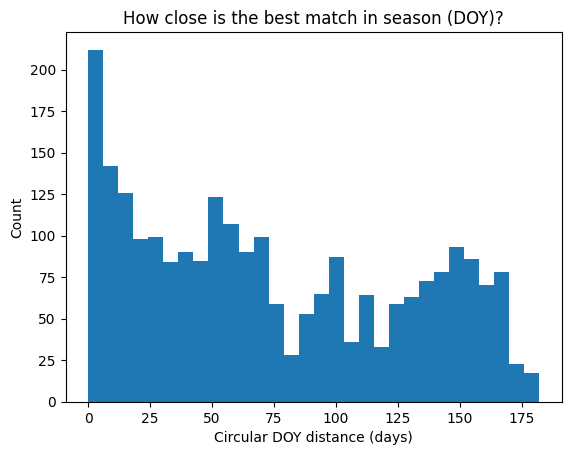

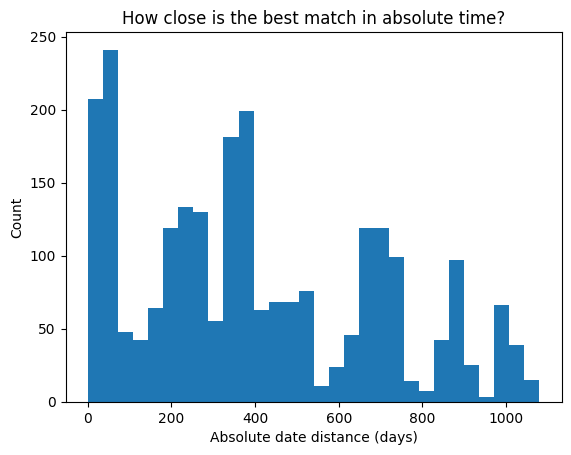

In [23]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["doy_dist"], bins=30)
plt.xlabel("Circular DOY distance (days)")
plt.ylabel("Count")
plt.title("How close is the best match in season (DOY)?")
plt.show()

plt.figure()
plt.hist(df["abs_days_dist"], bins=30)
plt.xlabel("Absolute date distance (days)")
plt.ylabel("Count")
plt.title("How close is the best match in absolute time?")
plt.show()


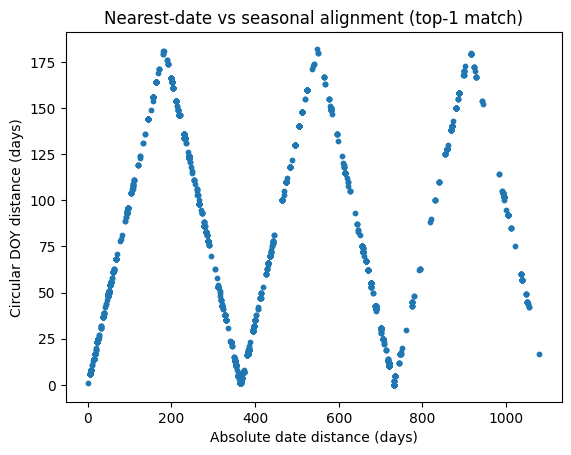

In [24]:
plt.figure()
plt.scatter(df["abs_days_dist"], df["doy_dist"], s=10)
plt.xlabel("Absolute date distance (days)")
plt.ylabel("Circular DOY distance (days)")
plt.title("Nearest-date vs seasonal alignment (top-1 match)")
plt.show()


ValueError: The number of FixedLocator locations (12), usually from a call to set_ticks, does not match the number of labels (10).

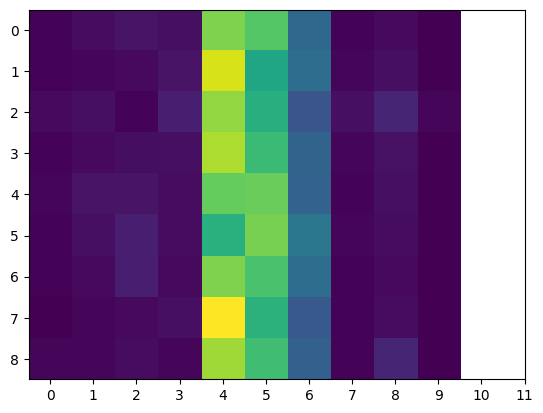

In [25]:
def month(dt): 
    return dt.month

df["m_query"] = df["t_query"].dt.month
df["m_nn"] = df["t_train_nn"].dt.month

cm = pd.crosstab(df["m_query"], df["m_nn"], normalize="index")  # row-normalized

plt.figure()
plt.imshow(cm.values, aspect="auto")
plt.xticks(range(12), cm.columns)
plt.yticks(range(12), cm.index)
plt.xlabel("Matched training month (top-1)")
plt.ylabel("Query month")
plt.title("Month confusion: P(matched month | query month)")
plt.colorbar()
plt.show()


/tmp/ipykernel_3622710/391955895.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=8)


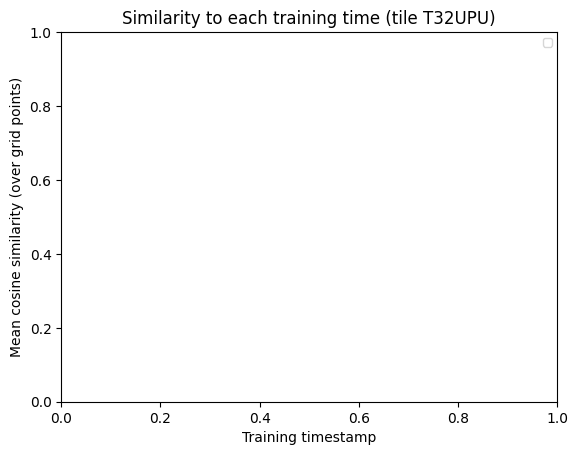

In [ ]:
# group by query timestamp and tile, then average cosine over grid points
from collections import defaultdict

def dt_from_train_file(f): 
    return parse_dt_from_train_file(f)

group = defaultdict(list)

for r in results:
    if "all_cosine" not in r:
        continue
    key = (r["tile_name"], r["t_query_str"])
    group[key].append((r["train_files"], np.array(r["all_cosine"], dtype=float)))

# plot one curve per query time for a chosen tile
tile_to_plot = "T32UPU"

plt.figure()
for (tile, t_q), items in group.items():
    if tile != tile_to_plot:
        continue

    train_files = items[0][0]
    # align by order (must be consistent)
    cos_mat = np.stack([it[1] for it in items], axis=0)  # (n_points, n_train_times)
    mean_cos = cos_mat.mean(axis=0)

    train_dts = [dt_from_train_file(f) for f in train_files]
    order = np.argsort(train_dts)
    train_dts_sorted = np.array(train_dts)[order]
    mean_cos_sorted = mean_cos[order]

    plt.plot(train_dts_sorted, mean_cos_sorted, label=t_q)

plt.xlabel("Training timestamp")
plt.ylabel("Mean cosine similarity (over grid points)")
plt.title(f"Similarity to each training time (tile {tile_to_plot})")
plt.legend(fontsize=8)
plt.show()
